# Model Selection — sMAPE & RMSE Comparison
Loads all prediction CSVs, computes metrics, ranks models per commodity, and gives a final recommendation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

BASE       = Path("../..").resolve()
PRED_DIR   = BASE / "outputs" / "predictions"
ARIMAX_DIR = BASE / "models" / "sarima_arimax" / "outputs" / "arimax" / "forecasts"
SARIMA_DIR = BASE / "models" / "sarima_arimax" / "outputs" / "sarima" / "forecasts"

FILE_MAP = {
    "Bulb Onions (Yellow)": "Bulb_Onions_Yellow",
    "Cabbage":              "Cabbage",
    "Carrots":              "Carrots",
    "Lettuce":              "Lettuce",
}
ALL_COMMODITIES = list(FILE_MAP.keys())

PALETTE = {
    "ARIMAX":  "#2980b9",
    "SARIMA":  "#8e44ad",
    "N-BEATS": "#27ae60",
    "TimeGPT": "#e74c3c",
    "Mamba":   "#e67e22",
    "S-Mamba": "#16a085",
}

In [2]:
def smape(a, p):
    a, p = np.asarray(a, float), np.asarray(p, float)
    return float(np.mean(200 * np.abs(a - p) / (np.abs(a) + np.abs(p))))

def rmse(a, p):
    a, p = np.asarray(a, float), np.asarray(p, float)
    return float(np.sqrt(np.mean((a - p) ** 2)))

def mae(a, p):
    return float(np.mean(np.abs(np.asarray(a, float) - np.asarray(p, float))))


def load_all_predictions():
    records = []

    # ARIMAX & SARIMA
    for model, folder in [("ARIMAX", ARIMAX_DIR), ("SARIMA", SARIMA_DIR)]:
        for comm, stem in FILE_MAP.items():
            path = folder / f"{stem}.csv"
            if path.exists():
                df = pd.read_csv(path, parse_dates=["date"])
                df = df[["date", "actual", "predicted"]].copy()
                df["commodity"] = comm
                df["model"]     = model
                records.append(df)

    # Neural models
    neural = {
        "N-BEATS": "nbeats_forecasts.csv",
        "TimeGPT": "timegpt_forecasts.csv",
        "Mamba":   "mamba_forecasts.csv",
        "S-Mamba": "smamba_forecasts.csv",
    }
    for model, fname in neural.items():
        path = PRED_DIR / fname
        if path.exists():
            df = pd.read_csv(path, parse_dates=["date"])
            df = df[["commodity", "date", "actual", "predicted"]].copy()
            df["model"] = model
            records.append(df)

    return pd.concat(records, ignore_index=True)


preds = load_all_predictions()
print(f"Loaded {len(preds):,} rows | models: {sorted(preds['model'].unique())} | commodities: {sorted(preds['commodity'].unique())}")

Loaded 1,436 rows | models: ['ARIMAX', 'Mamba', 'N-BEATS', 'S-Mamba', 'SARIMA', 'TimeGPT'] | commodities: ['Bulb Onions (Yellow)', 'Cabbage', 'Carrots', 'Lettuce']


In [3]:
# ── Compute metrics per model × commodity ───────────────────────────────────
rows = []
for (comm, model), g in preds.groupby(["commodity", "model"]):
    rows.append({
        "Commodity": comm,
        "Model":     model,
        "RMSE":      round(rmse(g["actual"], g["predicted"]), 4),
        "MAE":       round(mae(g["actual"],  g["predicted"]), 4),
        "sMAPE":     round(smape(g["actual"], g["predicted"]), 4),
        "N":         len(g),
    })

metrics = pd.DataFrame(rows).sort_values(["Commodity", "sMAPE"]).reset_index(drop=True)

# Rank within each commodity (1 = best)
metrics["sMAPE_rank"] = metrics.groupby("Commodity")["sMAPE"].rank().astype(int)
metrics["RMSE_rank"]  = metrics.groupby("Commodity")["RMSE"].rank().astype(int)
metrics["avg_rank"]   = ((metrics["sMAPE_rank"] + metrics["RMSE_rank"]) / 2).round(1)

print(metrics.to_string(index=False))

           Commodity   Model   RMSE    MAE   sMAPE  N  sMAPE_rank  RMSE_rank  avg_rank
Bulb Onions (Yellow) S-Mamba 0.0482 0.0367  6.7227 60           1          1       1.0
Bulb Onions (Yellow)  ARIMAX 0.0633 0.0485  8.7388 60           2          2       2.0
Bulb Onions (Yellow) TimeGPT 0.0778 0.0610 11.8120 60           3          3       3.0
Bulb Onions (Yellow) N-BEATS 0.0992 0.0819 14.0461 59           4          4       4.0
Bulb Onions (Yellow)   Mamba 0.1216 0.1065 18.1040 60           5          5       5.0
Bulb Onions (Yellow)  SARIMA 0.1463 0.1128 18.5752 60           6          6       6.0
             Cabbage  SARIMA 0.0454 0.0328  4.5971 60           1          2       1.5
             Cabbage  ARIMAX 0.0451 0.0347  4.9976 60           2          1       1.5
             Cabbage TimeGPT 0.0593 0.0434  6.2865 60           3          3       3.0
             Cabbage N-BEATS 0.0722 0.0602  8.7885 59           4          4       4.0
             Cabbage S-Mamba 0.0907 0.0767 

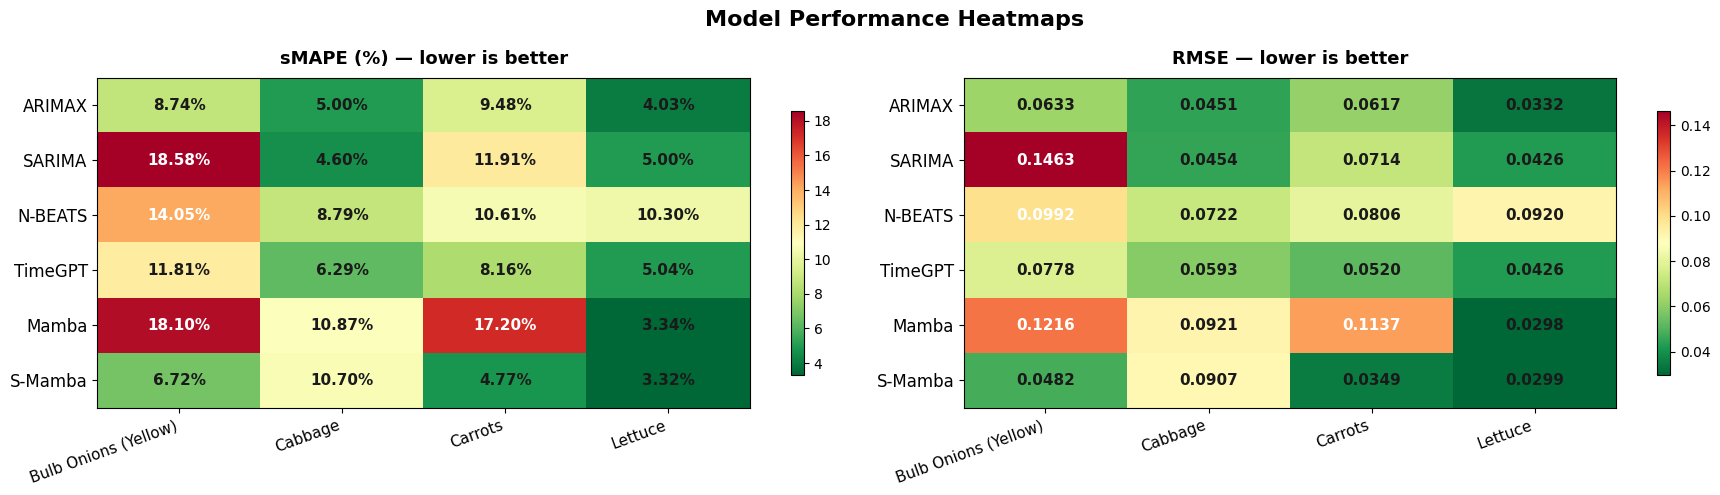

In [4]:
# ── Heatmaps: sMAPE and RMSE ────────────────────────────────────────────────
model_order = ["ARIMAX", "SARIMA", "N-BEATS", "TimeGPT", "Mamba", "S-Mamba"]

smape_pivot = metrics.pivot(index="Model", columns="Commodity", values="sMAPE").reindex(model_order)
rmse_pivot  = metrics.pivot(index="Model", columns="Commodity", values="RMSE").reindex(model_order)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, pivot, title, fmt in [
    (axes[0], smape_pivot, "sMAPE (%) — lower is better", "{:.2f}%"),
    (axes[1], rmse_pivot,  "RMSE — lower is better",      "{:.4f}"),
]:
    im = ax.imshow(pivot.values, cmap="RdYlGn_r", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, fontsize=11, rotation=20, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)

    for r in range(pivot.shape[0]):
        for c in range(pivot.shape[1]):
            val = pivot.values[r, c]
            if not np.isnan(val):
                ax.text(c, r, fmt.format(val), ha="center", va="center",
                        fontsize=11, fontweight="bold",
                        color="white" if val > pivot.values.max() * 0.65 else "#1a1a1a")

    fig.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle("Model Performance Heatmaps", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

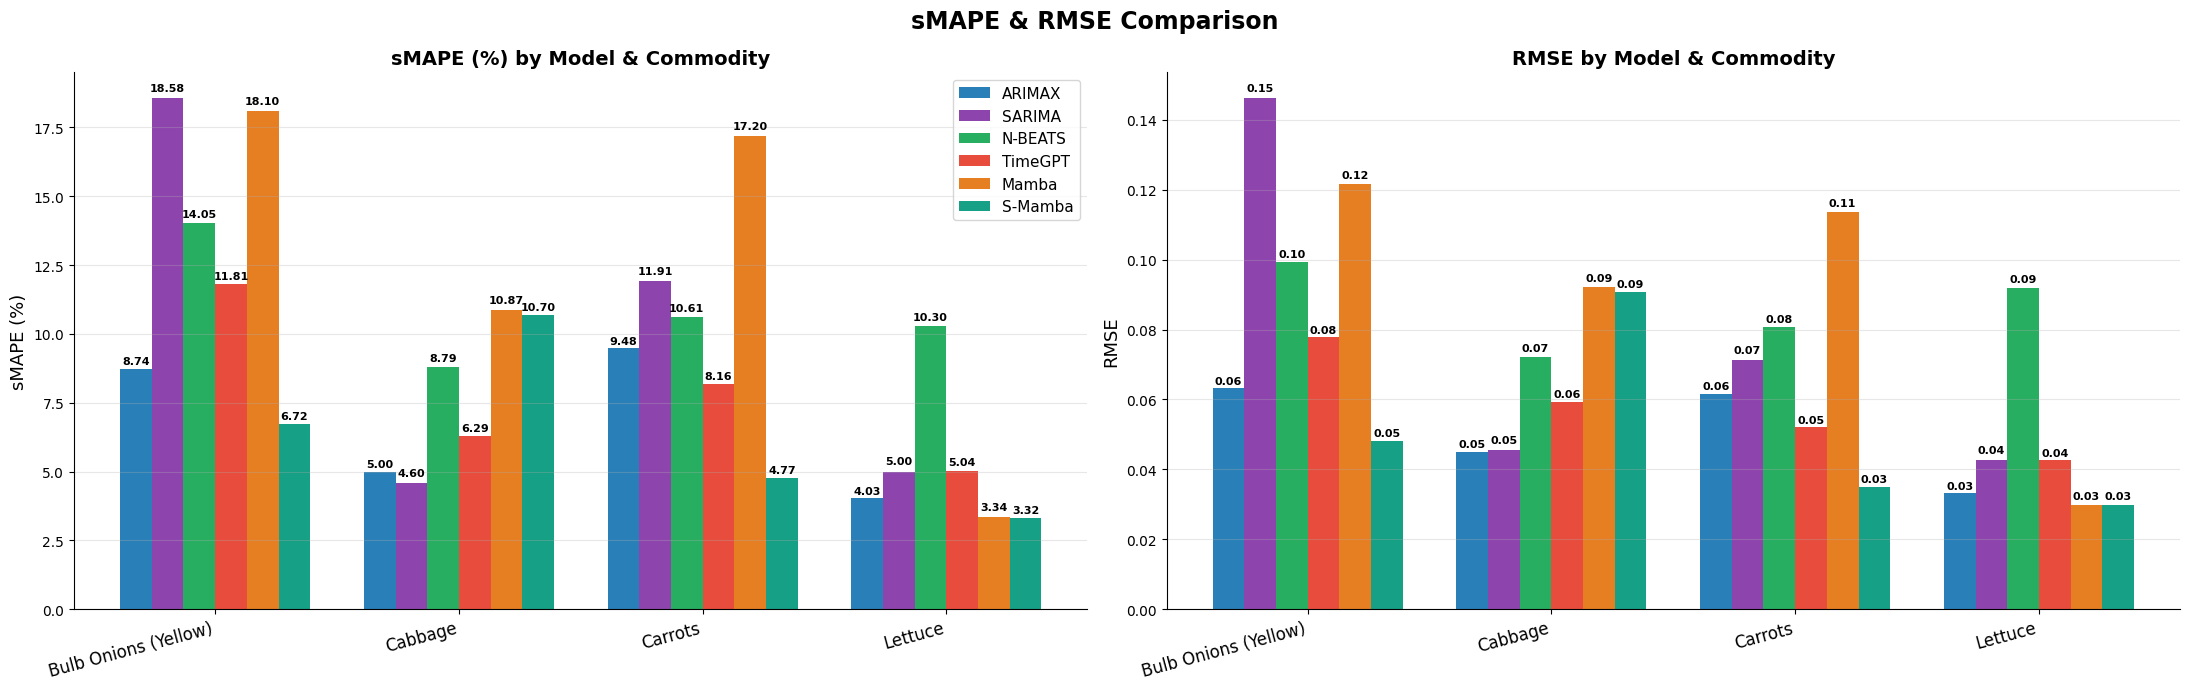

In [5]:
# ── Side-by-side sMAPE & RMSE grouped bar charts ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 7))

for ax, metric_col, ylabel in [
    (axes[0], "sMAPE", "sMAPE (%)"),
    (axes[1], "RMSE",  "RMSE"),
]:
    x     = np.arange(len(ALL_COMMODITIES))
    width = 0.13
    offset = width * (len(model_order) - 1) / 2

    for i, model in enumerate(model_order):
        sub = metrics[metrics["Model"] == model]
        vals = [sub[sub["Commodity"] == c][metric_col].values[0]
                if len(sub[sub["Commodity"] == c]) else 0
                for c in ALL_COMMODITIES]
        bars = ax.bar(x + i * width - offset, vals, width,
                      label=model, color=PALETTE[model])
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01 * max(vals),
                    f"{v:.2f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(ALL_COMMODITIES, fontsize=12, rotation=15, ha="right")
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_title(f"{ylabel} by Model & Commodity", fontsize=14, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].legend(fontsize=11, loc="upper right")
plt.suptitle("sMAPE & RMSE Comparison", fontsize=17, fontweight="bold")
plt.tight_layout()
plt.show()

In [6]:
# ── Rank table & winner per commodity ──────────────────────────────────────
rank_pivot = metrics.pivot(index="Model", columns="Commodity", values="avg_rank").reindex(model_order)

print("=" * 65)
print("  AVERAGE RANK (sMAPE + RMSE) — lower = better")
print("=" * 65)
print(rank_pivot.to_string())
print()

# Winner per commodity
winners = metrics.loc[metrics.groupby("Commodity")["avg_rank"].idxmin(),
                      ["Commodity", "Model", "sMAPE", "RMSE", "avg_rank"]]

print("=" * 65)
print("  RECOMMENDED MODEL PER COMMODITY")
print("=" * 65)
print(winners.to_string(index=False))

# Overall best model (lowest mean rank across all commodities)
overall = metrics.groupby("Model")["avg_rank"].mean().sort_values()
print()
print("=" * 65)
print("  OVERALL MODEL RANKING (mean rank across all commodities)")
print("=" * 65)
for rank, (model, score) in enumerate(overall.items(), 1):
    star = "  ★ BEST OVERALL" if rank == 1 else ""
    print(f"  {rank}. {model:<12}  avg rank = {score:.2f}{star}")

  AVERAGE RANK (sMAPE + RMSE) — lower = better
Commodity  Bulb Onions (Yellow)  Cabbage  Carrots  Lettuce
Model                                                     
ARIMAX                      2.0      1.5      3.0      3.0
SARIMA                      6.0      1.5      4.5      4.0
N-BEATS                     4.0      4.0      4.5      6.0
TimeGPT                     3.0      3.0      2.0      4.5
Mamba                       5.0      6.0      6.0      1.5
S-Mamba                     1.0      5.0      1.0      1.5

  RECOMMENDED MODEL PER COMMODITY
           Commodity   Model  sMAPE   RMSE  avg_rank
Bulb Onions (Yellow) S-Mamba 6.7227 0.0482       1.0
             Cabbage  SARIMA 4.5971 0.0454       1.5
             Carrots S-Mamba 4.7679 0.0349       1.0
             Lettuce S-Mamba 3.3154 0.0299       1.5

  OVERALL MODEL RANKING (mean rank across all commodities)
  1. S-Mamba       avg rank = 2.12  ★ BEST OVERALL
  2. ARIMAX        avg rank = 2.38
  3. TimeGPT       avg rank = 3.12


In [ ]:
%%sql


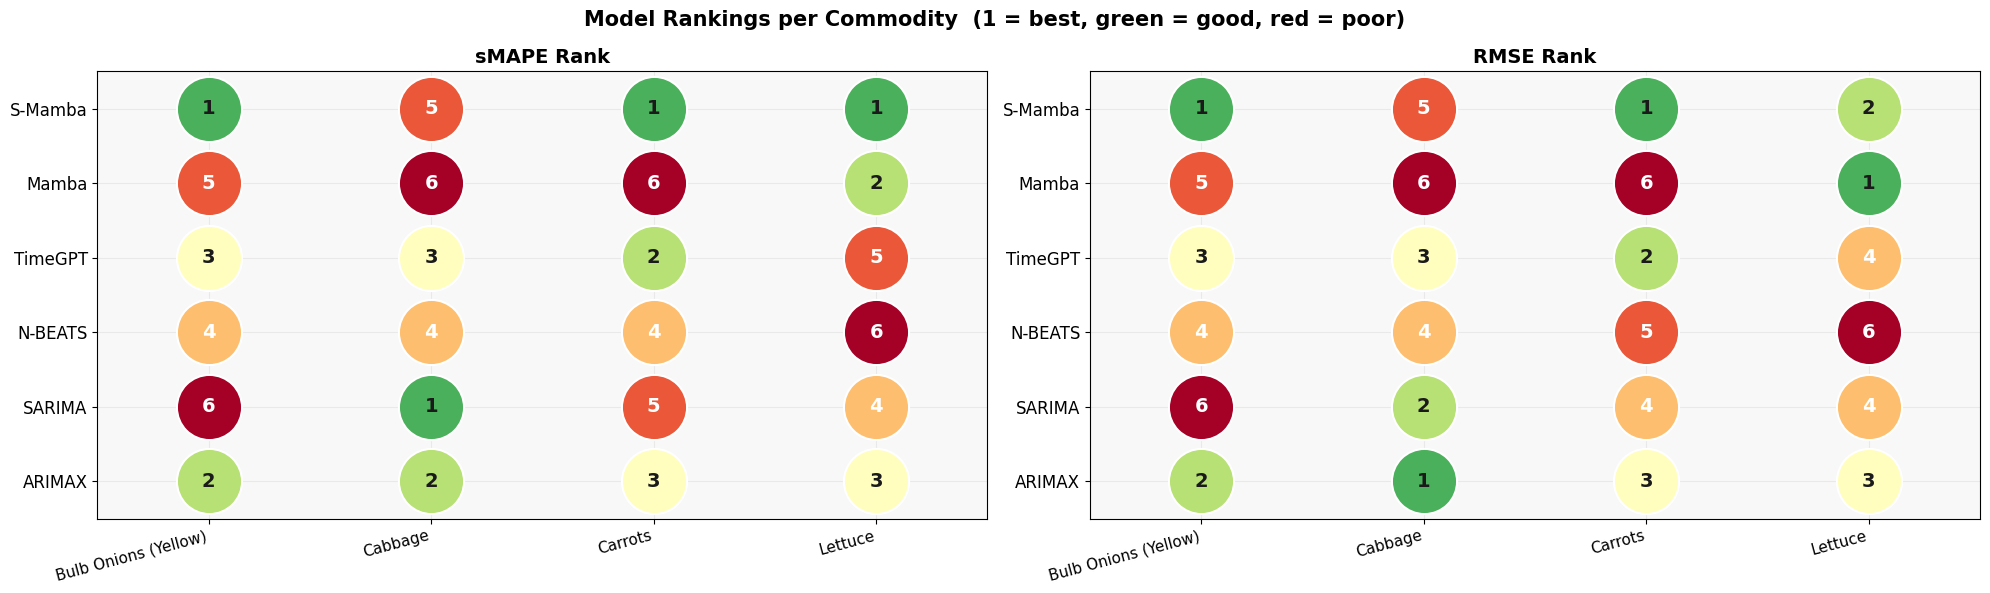

In [7]:
# ── Rank visualisation — bubble chart (model × commodity, size = rank) ──────
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, metric_col, title in [
    (axes[0], "sMAPE_rank", "sMAPE Rank"),
    (axes[1], "RMSE_rank",  "RMSE Rank"),
]:
    pivot = metrics.pivot(index="Model", columns="Commodity", values=metric_col).reindex(model_order)
    n_models = len(model_order)
    n_comms  = len(ALL_COMMODITIES)

    for ri, model in enumerate(model_order):
        for ci, comm in enumerate(ALL_COMMODITIES):
            val = pivot.loc[model, comm] if comm in pivot.columns else np.nan
            if np.isnan(val):
                continue
            # Green for rank 1, red for last
            colour = plt.cm.RdYlGn_r(val / n_models)
            ax.scatter(ci, ri, s=2200, color=colour, zorder=3, edgecolors="white", linewidths=1.5)
            ax.text(ci, ri, str(int(val)), ha="center", va="center",
                    fontsize=14, fontweight="bold",
                    color="white" if val >= n_models * 0.6 else "#1a1a1a")

    ax.set_xticks(range(n_comms))
    ax.set_xticklabels(ALL_COMMODITIES, fontsize=11, rotation=15, ha="right")
    ax.set_yticks(range(n_models))
    ax.set_yticklabels(model_order, fontsize=12)
    ax.set_xlim(-0.5, n_comms - 0.5)
    ax.set_ylim(-0.5, n_models - 0.5)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.grid(True, alpha=0.2)
    ax.set_facecolor("#f8f8f8")

fig.suptitle("Model Rankings per Commodity  (1 = best, green = good, red = poor)",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

In [8]:
# ── Final summary table ─────────────────────────────────────────────────────
summary = metrics.sort_values(["Commodity", "avg_rank"])[
    ["Commodity", "Model", "sMAPE", "RMSE", "MAE", "sMAPE_rank", "RMSE_rank", "avg_rank"]
].copy()

summary["sMAPE"]  = summary["sMAPE"].map("{:.4f}%".format)
summary["RMSE"]   = summary["RMSE"].map("{:.4f}".format)
summary["MAE"]    = summary["MAE"].map("{:.4f}".format)

print("\nFull metrics table (sorted by commodity then avg rank):")
print(summary.to_string(index=False))

# Export
out = BASE / "outputs" / "model_comparison" / "model_selection_results.csv"
metrics.to_csv(out, index=False)


Full metrics table (sorted by commodity then avg rank):
           Commodity   Model    sMAPE   RMSE    MAE  sMAPE_rank  RMSE_rank  avg_rank
Bulb Onions (Yellow) S-Mamba  6.7227% 0.0482 0.0367           1          1       1.0
Bulb Onions (Yellow)  ARIMAX  8.7388% 0.0633 0.0485           2          2       2.0
Bulb Onions (Yellow) TimeGPT 11.8120% 0.0778 0.0610           3          3       3.0
Bulb Onions (Yellow) N-BEATS 14.0461% 0.0992 0.0819           4          4       4.0
Bulb Onions (Yellow)   Mamba 18.1040% 0.1216 0.1065           5          5       5.0
Bulb Onions (Yellow)  SARIMA 18.5752% 0.1463 0.1128           6          6       6.0
             Cabbage  SARIMA  4.5971% 0.0454 0.0328           1          2       1.5
             Cabbage  ARIMAX  4.9976% 0.0451 0.0347           2          1       1.5
             Cabbage TimeGPT  6.2865% 0.0593 0.0434           3          3       3.0
             Cabbage N-BEATS  8.7885% 0.0722 0.0602           4          4       4.0
        